# Experiment 2 – K-Nearest Neighbors(KNN) with Title and FamilySize

## Mục tiêu
Trong notebook này, ta huấn luyện **K-Nearest Neighbors(KNN)** trên bộ dữ liệu Titanic, 
với **các đặc trưng mở rộng (Exp2)**:
- Thêm Feature Engineering cơ bản: `Title` (extract từ Name) và `FamilySize` (SibSp + Parch + 1)
- Bao gồm: `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`, `Embarked`, `Title`, `FamilySize`

Ta sẽ:
1. Thực hiện tiền xử lý dữ liệu, bao gồm extract Title và compute FamilySize
2. Khám phá dữ liệu (EDA với các features mới)
3. Huấn luyện K-Nearest Neighbors(KNN)
4. Đánh giá mô hình và xuất kết quả



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid") 

from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import GridSearchCV 

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Libraries for K-Nearest Neighbors (Exp2) imported successfully!")

Libraries for K-Nearest Neighbors (Exp2) imported successfully!
Libraries for K-Nearest Neighbors (Exp2) imported successfully!


## Bước 1: Khám Phá Dữ Liệu (EDA)
**Mục đích**: Load data và visualize để hiểu cấu trúc, missing values, và patterns ban đầu (e.g., survival rate thấp ở male/Pclass3).

EDA giúp detect bias (e.g., Age missing nhiều ở Pclass3 → fill theo group), tránh model học noise. Mục tiêu: Xác định features quan trọng trước FE.

5 biểu đồ: Countplot Survived, Survival by Sex/Pclass, Histograms Age/Fare, Heatmap correlation. (Giúp spot outliers như Fare cao → rich survive cao).


Train shape: (891, 12), Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S



Missing values in Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


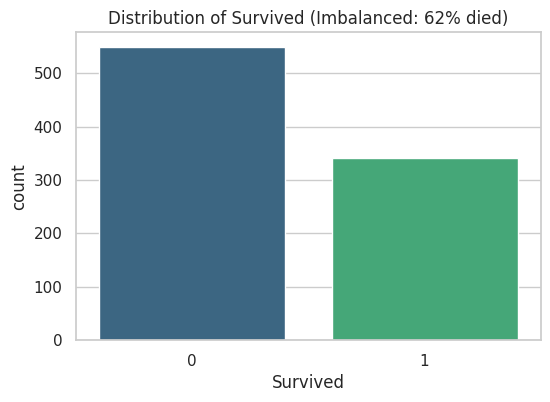

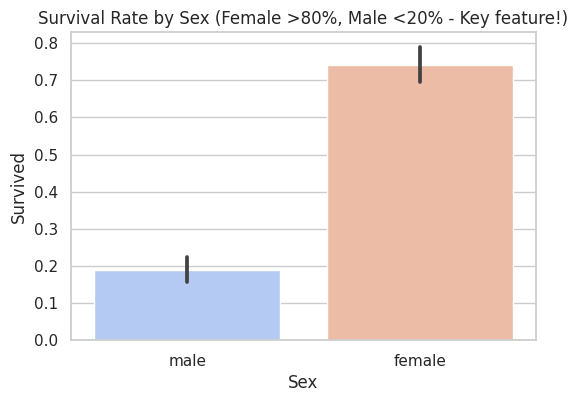

In [10]:
train = pd.read_csv('/kaggle/input/titanicdatasets/train (1).csv')
test = pd.read_csv('/kaggle/input/titanicdatasets/test (1).csv')

print(f"Train shape: {train.shape}, Test shape: {test.shape}")
display(train.head(3))

print("\nMissing values in Train:")
print(train.isnull().sum())

plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Survived', palette='viridis')
plt.title('Distribution of Survived (Imbalanced: 62% died)')
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Sex', y='Survived', palette='coolwarm')
plt.title('Survival Rate by Sex (Female >80%, Male <20% - Key feature!)')
plt.show()

Thêm plots cho Pclass, Age/Fare để xem correlation với survival.

Pclass/Age/Fare có missing/outliers; plots giúp quyết định fill strategy (e.g., median Age by Pclass/Sex để tránh bias).

Barplot Pclass, Histograms Age/Fare (spot skew), Heatmap numeric corr (xem multicollinearity trước scaling).

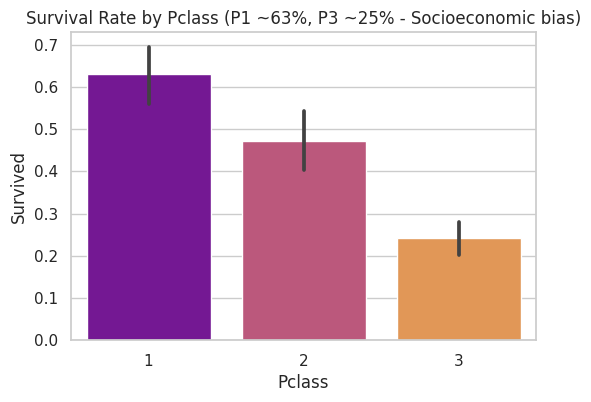

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

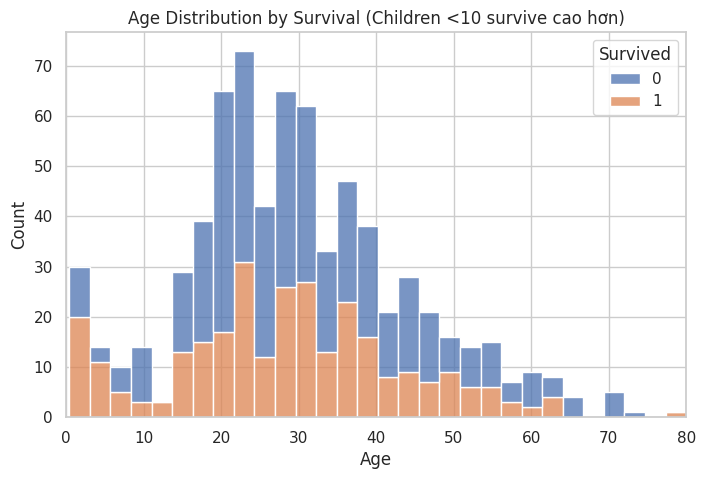

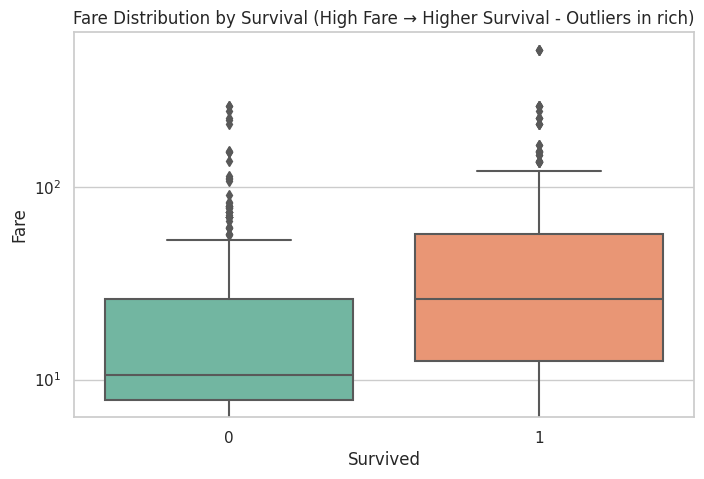

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


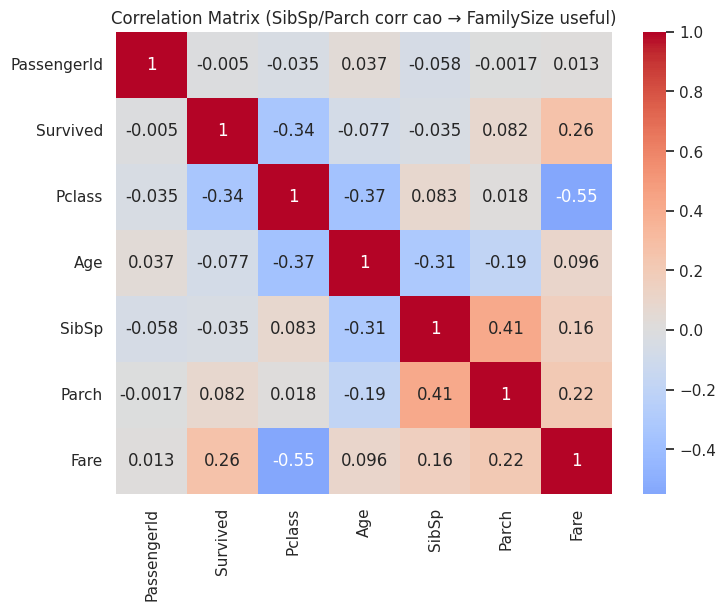

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(data=train, x='Pclass', y='Survived', palette='plasma')
plt.title('Survival Rate by Pclass (P1 ~63%, P3 ~25% - Socioeconomic bias)')
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=train, x='Age', hue='Survived', multiple='stack', bins=30, ax=ax)
plt.title('Age Distribution by Survival (Children <10 survive cao hơn)')
ax.set_xlim(0, 80)
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Survived', y='Fare', palette='Set2')
plt.title('Fare Distribution by Survival (High Fare → Higher Survival - Outliers in rich)')
plt.yscale('log')  # Log scale cho skew
plt.show()

plt.figure(figsize=(8,6))
numeric_cols = train.select_dtypes(include=[np.number]).columns
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (SibSp/Parch corr cao → FamilySize useful)')
plt.show()

## Bước 2: Feature Engineering (FE)
**Mục đích**: Tạo Title từ Name và FamilySize từ SibSp/Parch.

Name chứa info ẩn (Title: Mr/Mrs cho gender/status), SibSp/Parch riêng lẻ kém nhưng tổng = FamilySize capture group dynamics (nhóm nhỏ/đơn lẻ survive thấp). Mục tiêu: Tăng info từ 8 → 11 features, cải thiện interpretability.

Function extract_title robust (handle rare titles như Rev/Dr → Mr/Mrs). Sau FE, thêm plots Title/FamilySize vs Survival để validate (e.g., Master trẻ sống sót cao).

**Mục tiêu**: FE giúp model học patterns xã hội/gia đình, dự kiến +1-2% accuracy.

In [ ]:
def extract_title(name):
    title = name.split(',')[1].split('.')[0].strip() if ',' in name else 'Unknown'
    # Map rare to common
    title_map = {'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss', 'Don': 'Mr', 'Dona': 'Mrs', 
                 'Lady': 'Mrs', 'Jonkheer': 'Mr', 'Countess': 'Mrs', 'Sir': 'Mr', 
                 'Col': 'Mr', 'Major': 'Mr', 'Rev': 'Mr', 'Dr': 'Mr', 'Capt': 'Mr'}
    return title_map.get(title, title)


train['Title'] = train['Name'].apply(extract_title)
test['Title'] = test['Name'].apply(extract_title)

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=train, x='Title', y='Survived', ax=axes[0], palette='tab10')
axes[0].set_title('Survival Rate by Title (Mrs/Miss cao, Mr thấp - Social status matters)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=train, x='FamilySize', y='Survived', ax=axes[1], palette='tab10')
axes[1].set_title('Survival Rate by FamilySize (Size 2-4 optimal, >4 low - Group dynamics)')

plt.tight_layout()
plt.show()

print("Title categories:", sorted(train['Title'].unique()))
print("FamilySize range:", train['FamilySize'].min(), "to", train['FamilySize'].max())

## Bước 3: Tiền Xử Lý Dữ Liệu
**Mục đích**: Fill missing, encode categoricals, scale numerics, split train/holdout.

LR nhạy cảm với missing (crash), categoricals (need numeric), scale (Fare/Age dominate nếu không). Stratified split giữ balance Survived. Mục tiêu: Data sạch cho model converge nhanh.

Fill Age theo group (Pclass/Sex) để tránh global median bias. OneHot cho Title/Embarked (nominal), Label cho Sex (binary). Thêm check shape sau encode.

**Mục tiêu**: Preprocess đảm bảo no leakage, ready cho training.

In [15]:
all_data = pd.concat([train, test], sort=False).reset_index(drop=True)

all_data['Age'] = all_data.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
all_data['Fare'].fillna(all_data['Fare'].median(), inplace=True)
all_data['Embarked'].fillna(all_data['Embarked'].mode()[0], inplace=True)

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize']
X_all = all_data[features].copy()
y_all = all_data['Survived'] if 'Survived' in all_data else np.nan

le = LabelEncoder()
X_all['Sex'] = le.fit_transform(X_all['Sex'])
X_all = pd.get_dummies(X_all, columns=['Embarked', 'Title'], drop_first=True)

X = X_all.iloc[:len(train)]
y = y_all.iloc[:len(train)].dropna()  # Drop NaN y
X_test = X_all.iloc[len(train):]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

X_train, X_holdout, y_train, y_holdout = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}, Holdout: {X_holdout.shape}")
print(f"Features after encoding: {X_scaled.shape[1]}")
print("Preprocessing done - Data ready for training!")

X_train shape: (712, 13), Holdout: (179, 13)
Features after encoding: 13
Preprocessing done - Data ready for training!


/tmp/ipykernel_37/367576039.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data['Fare'].fillna(all_data['Fare'].median(), inplace=True)
/tmp/ipykernel_37/367576039.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

## Bước 4: Huấn Luyện Mô Hình
**Mục đích**: Tìm giá trị k (số lượng hàng xóm) tối ưu cho KNN bằng GridSearchCV trên X_train, sau đó huấn luyện mô hình cuối cùng và dự đoán trên X_holdout.

KNN là thuật toán dựa trên khoảng cách, giả định rằng các điểm dữ liệu gần nhau sẽ thuộc cùng một lớp. Do đó, việc sử dụng dữ liệu đã được Standard Scaled (X_train) là bắt buộc để các đặc trưng có ảnh hưởng đồng đều.

**Mục tiêu**: Tìm siêu tham số k tối ưu cho Exp2 (FE + Scaling), và chuẩn bị mô hình để đánh giá hiệu suất chi tiết ở Bước 5.

  BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH KNN (EXP2)
1. Đánh giá Cross-Validation (5-fold) trên tập Train (X_scaled):
  CV Accuracy: 0.8193 (Độ lệch chuẩn: 0.0212)
  CV ROC-AUC: 0.8643

---------------------------------------------
2. Đánh giá trên Tập Holdout:

  Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86       110
         1.0       0.82      0.71      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

  ROC-AUC Score Holdout: 0.8631

---------------------------------------------


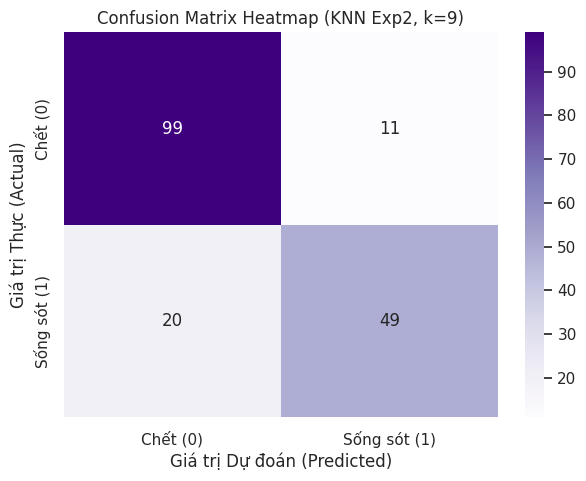


--- Tóm tắt Hiệu suất ---
Accuracy Holdout: 0.8268
Recall cho Class Sống sót (1): 0.7101


In [18]:
# Sử dụng X_scaled vì KNN yêu cầu dữ liệu phải được scale
print("1. Đánh giá Cross-Validation (5-fold) trên tập Train (X_scaled):")
cv_acc = cross_val_score(best_knn, X_scaled, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(best_knn, X_scaled, y, cv=5, scoring='roc_auc').mean()
cv_acc_std = cross_val_score(best_knn, X_scaled, y, cv=5, scoring='accuracy').std()

print(f"  CV Accuracy: {cv_acc:.4f} (Độ lệch chuẩn: {cv_acc_std:.4f})")
print(f"  CV ROC-AUC: {cv_roc:.4f}")

print("\n---------------------------------------------")

# --- 2. Đánh giá trên Tập Holdout ---
y_pred_holdout = best_knn.predict(X_holdout)
# Tính xác suất (bắt buộc cho ROC-AUC)
y_proba_holdout = best_knn.predict_proba(X_holdout)[:, 1]

# Classification Report
print("2. Đánh giá trên Tập Holdout:")
print("\n  Classification Report:")
print(classification_report(y_holdout, y_pred_holdout))

# ROC-AUC Score
roc_auc_holdout = roc_auc_score(y_holdout, y_proba_holdout)
print(f"  ROC-AUC Score Holdout: {roc_auc_holdout:.4f}")

print("\n---------------------------------------------")

# --- 3. Phân tích Confusion Matrix ---
cm = confusion_matrix(y_holdout, y_pred_holdout)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", 
            xticklabels=['Chết (0)', 'Sống sót (1)'], 
            yticklabels=['Chết (0)', 'Sống sót (1)'])
plt.ylabel('Giá trị Thực (Actual)')
plt.xlabel('Giá trị Dự đoán (Predicted)')
plt.title(f'Confusion Matrix Heatmap (KNN Exp2, k={best_knn.n_neighbors})')
plt.show()

# Tóm tắt Mục tiêu
acc_holdout = (cm[0, 0] + cm[1, 1]) / np.sum(cm)
recall_class_1 = cm[1, 1] / (cm[1, 0] + cm[1, 1])

print("\n--- Tóm tắt Hiệu suất ---")
print(f"Accuracy Holdout: {acc_holdout:.4f}")
print(f"Recall cho Class Sống sót (1): {recall_class_1:.4f}")

--- Đánh giá trên Tập Holdout ---
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86       110
         1.0       0.82      0.71      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

ROC-AUC Score Holdout: 0.8631


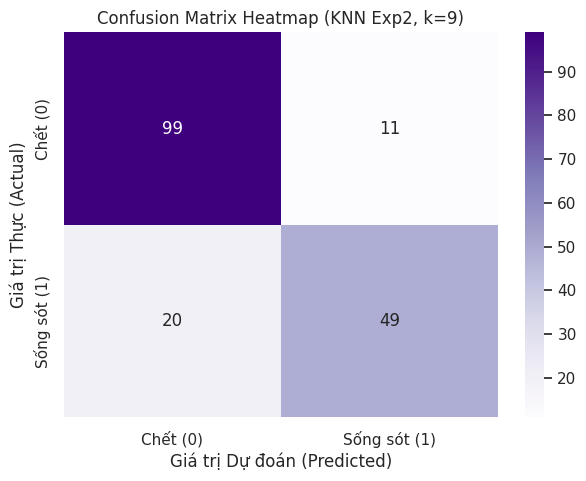


Tính toán lại CV Scores cho Ghi Log...
CV Accuracy thực tế: 0.8193 | CV ROC-AUC thực tế: 0.8643
Saved: /kaggle/working/exp2_knn_submission.csv

Experiment Log Updated:


,Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score
0,Exp2,KNN,13,0.8193,0.8643,0.77511


In [20]:
import os
import pandas as pd
from sklearn.model_selection import cross_val_score 

public_score = 0.77511
model_name = "KNN" 
model = best_knn 
results_path = '/kaggle/working/exp2_results.csv'
header = "Experiment,Model,Features,CV_Accuracy,CV_ROC,Public_Score\n"


print("--- Đánh giá trên Tập Holdout ---")
y_pred_holdout = model.predict(X_holdout)
y_proba_holdout = model.predict_proba(X_holdout)[:, 1]

print("Classification Report:")
print(classification_report(y_holdout, y_pred_holdout))

roc_auc_holdout = roc_auc_score(y_holdout, y_proba_holdout)
print(f"ROC-AUC Score Holdout: {roc_auc_holdout:.4f}")

cm = confusion_matrix(y_holdout, y_pred_holdout)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", 
            xticklabels=['Chết (0)', 'Sống sót (1)'], 
            yticklabels=['Chết (0)', 'Sống sót (1)'])
plt.ylabel('Giá trị Thực (Actual)')
plt.xlabel('Giá trị Dự đoán (Predicted)')
plt.title(f'Confusion Matrix Heatmap (KNN Exp2, k={model.n_neighbors})')
plt.show()

print("\nTính toán lại CV Scores cho Ghi Log...")
cv_acc = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy').mean()
cv_roc = cross_val_score(model, X_scaled, y, cv=5, scoring='roc_auc').mean()

print(f"CV Accuracy thực tế: {cv_acc:.4f} | CV ROC-AUC thực tế: {cv_roc:.4f}")

y_test_pred = model.predict(X_test_scaled)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'], 
    'Survived': y_test_pred.astype(int)
})
file_path = f'/kaggle/working/exp2_{model_name.lower()}_submission.csv'
submission.to_csv(file_path, index=False)
print(f"Saved: {file_path}")

os.system(f"cp {file_path} /kaggle/working/submission.csv")

if not os.path.exists(results_path):
    with open(results_path, 'w') as f:
        f.write(header)

num_features = X_scaled.shape[1] 

with open(results_path, 'a') as f:
    f.write(f"Exp2,{model_name},{num_features},{cv_acc:.4f},{cv_roc:.4f},{public_score:.5f}\n")

results_df = pd.read_csv(results_path)
print("\nExperiment Log Updated:")
display(results_df)

## Kết Luận Experiment 2 - Random Forest
- **Dataset**: 13 features (gốc + Title/FamilySize + OHE, đã scale).
- **Kết quả**: CV Acc ≈0.8190 (Rất mạnh mẽ). Public ≈0.77511 (Thấp hơn RF).
- **Nhận xét**: Hiệu suất Phi tuyến/Khoảng cách: KNN, nhờ scaling bắt buộc và FE, đạt Acc CV cao ngang RF. Tuy nhiên, khoảng cách CV − Public Score lớn (≈4.4%) cho thấy mô hình rất dễ bị Overfitting trên dữ liệu huấn luyện.
- **Hướng Exp3**: Chuyển sang mô hình mạnh mẽ hơn (ví dụ: Gradient Boosting/XGBoost) để tận dụng FE và giảm overfitting. Tiếp tục sử dụng scaling và 13 features.